In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as patches
from matplotlib.collections import PathCollection
import warnings
warnings.filterwarnings('ignore')

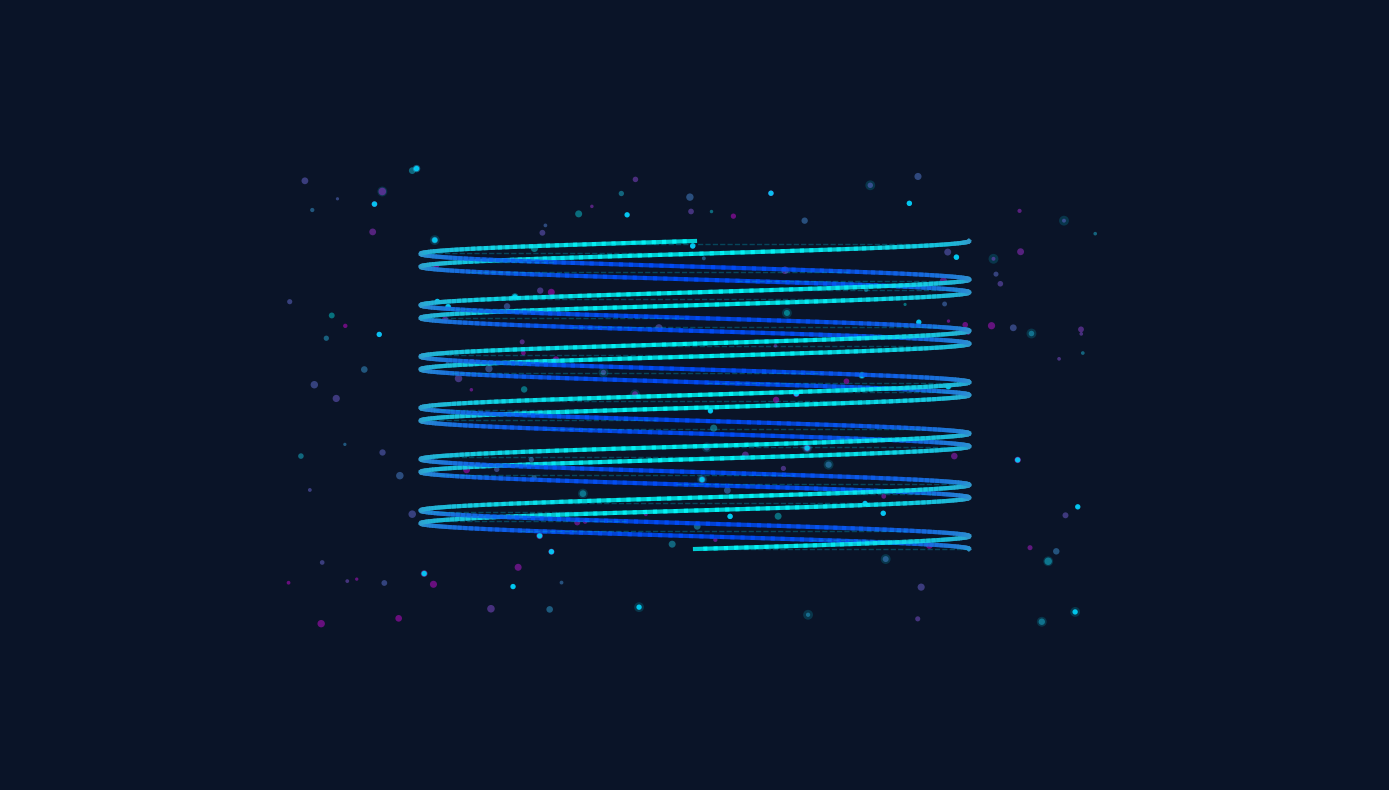

DNA Helix visualization created!


In [4]:
# Create figure with dark background
fig, ax = plt.subplots(figsize=(14, 8), facecolor='#0a1428')
ax.set_facecolor('#0a1428')
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

# Parameters for DNA helix
t = np.linspace(0, 8*np.pi, 1000)
amplitude = 2
frequency = 1.5
center_x = 5
center_y = 5

# Create helix curves
x = center_x + amplitude * np.cos(frequency * t)
y = center_y + np.linspace(-2, 2, len(t))  # Vertical progression
z = amplitude * np.sin(frequency * t)

# Normalize z for visualization purposes
z_norm = (z + amplitude) / (2 * amplitude)  # 0 to 1

# Create the helix with gradient colors
for i in range(len(t)-1):
    # Create color gradient from cyan to blue
    color_value = z_norm[i]
    if color_value < 0.5:
        # Cyan to teal
        r = 0 + (0.2 - 0) * (color_value * 2)
        g = 1 - (1 - 0.6) * (color_value * 2)
        b = 1 - (1 - 0.8) * (color_value * 2)
    else:
        # Teal to blue
        r = 0.2 - (0.2 - 0) * ((color_value - 0.5) * 2)
        g = 0.6 - (0.6 - 0.3) * ((color_value - 0.5) * 2)
        b = 0.8 + (1 - 0.8) * ((color_value - 0.5) * 2)
    
    ax.plot(x[i:i+2], y[i:i+2], color=(r, g, b), linewidth=3, alpha=0.8)

# Add second helix strand (offset phase)
t2 = t + np.pi
x2 = center_x + amplitude * np.cos(frequency * t2)
y2 = center_y + np.linspace(-2, 2, len(t2))
z2 = amplitude * np.sin(frequency * t2)
z2_norm = (z2 + amplitude) / (2 * amplitude)

for i in range(len(t2)-1):
    color_value = z2_norm[i]
    if color_value < 0.5:
        r = 0 + (0.2 - 0) * (color_value * 2)
        g = 1 - (1 - 0.6) * (color_value * 2)
        b = 1 - (1 - 0.8) * (color_value * 2)
    else:
        r = 0.2 - (0.2 - 0) * ((color_value - 0.5) * 2)
        g = 0.6 - (0.6 - 0.3) * ((color_value - 0.5) * 2)
        b = 0.8 + (1 - 0.8) * ((color_value - 0.5) * 2)
    
    ax.plot(x2[i:i+2], y2[i:i+2], color=(r, g, b), linewidth=3, alpha=0.8)

# Add connecting strands (like DNA rungs)
for i in range(0, len(t), 30):
    ax.plot([x[i], x2[i]], [y[i], y2[i]], color='#00bcd4', linewidth=1, alpha=0.3, linestyle='--')

# Add particle effects
np.random.seed(42)
num_particles = 150

# Particles around the helix
particle_x = np.random.uniform(2, 8, num_particles)
particle_y = np.random.uniform(2, 8, num_particles)
particle_sizes = np.random.uniform(5, 30, num_particles)
particle_colors = np.random.uniform(0.3, 1, num_particles)

scatter = ax.scatter(particle_x, particle_y, s=particle_sizes, 
                     c=particle_colors, cmap='cool', alpha=0.4, edgecolors='none')

# Add some bright accent dots
bright_indices = np.random.choice(num_particles, 30, replace=False)
ax.scatter(particle_x[bright_indices], particle_y[bright_indices], 
          s=15, color='#00d4ff', alpha=0.9, edgecolors='none')

# Add glowing effect to some particles
glow_indices = np.random.choice(num_particles, 20, replace=False)
ax.scatter(particle_x[glow_indices], particle_y[glow_indices], 
          s=50, color='#00bcd4', alpha=0.2, edgecolors='none')

plt.tight_layout()
plt.show()

print("DNA Helix visualization created!")

## Alternative: 3D Visualization
For a more realistic 3D helix representation:

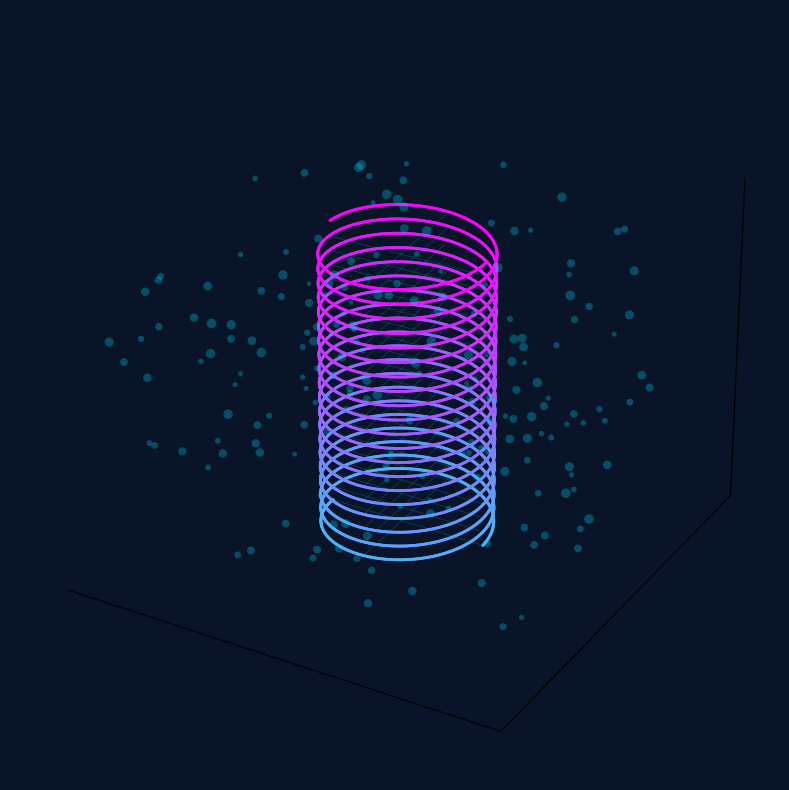

3D DNA Helix created!


In [5]:
# 3D DNA helix visualization
fig = plt.figure(figsize=(14, 8), facecolor='#0a1428')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#0a1428')

# Parameters
t = np.linspace(0, 20*np.pi, 2000)
radius = 2
height = 20

# Create double helix
x1 = radius * np.cos(t)
y1 = radius * np.sin(t)
z1 = np.linspace(0, height, len(t))

x2 = radius * np.cos(t + np.pi)
y2 = radius * np.sin(t + np.pi)
z2 = np.linspace(0, height, len(t))

# Create color gradient
colors1 = plt.cm.cool(np.linspace(0.3, 1, len(t)))
colors2 = plt.cm.cool(np.linspace(0.3, 1, len(t)))

# Plot the two strands
for i in range(len(t)-1):
    ax.plot(x1[i:i+2], y1[i:i+2], z1[i:i+2], color=colors1[i], linewidth=2)
    ax.plot(x2[i:i+2], y2[i:i+2], z2[i:i+2], color=colors2[i], linewidth=2)

# Add connecting rungs
for i in range(0, len(t), 50):
    ax.plot([x1[i], x2[i]], [y1[i], y2[i]], [z1[i], z2[i]], 
           color='#00bcd4', linewidth=0.5, alpha=0.3)

# Add particle effects
np.random.seed(42)
num_particles = 200
particle_x = np.random.uniform(-5, 5, num_particles)
particle_y = np.random.uniform(-5, 5, num_particles)
particle_z = np.random.uniform(0, height, num_particles)
particle_sizes = np.random.uniform(10, 50, num_particles)

ax.scatter(particle_x, particle_y, particle_z, s=particle_sizes, 
          c='#00d4ff', alpha=0.3, edgecolors='none')

# Styling
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('none')
ax.yaxis.pane.set_edgecolor('none')
ax.zaxis.pane.set_edgecolor('none')
ax.grid(False)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_zlabel('')
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

plt.tight_layout()
plt.show()

print("3D DNA Helix created!")

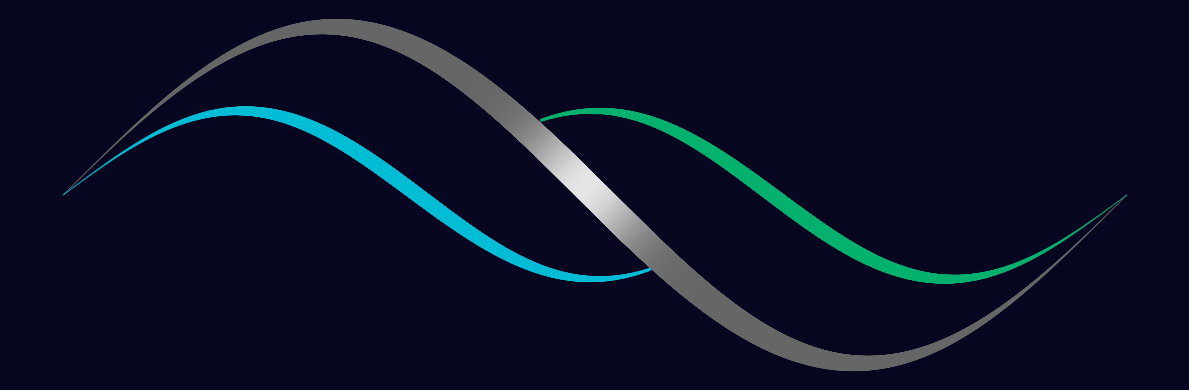

In [88]:
fig, ax = plt.subplots(figsize=(12, 4), facecolor="#060620")
ax.set_facecolor('#060620')

x = np.linspace(0, 2*np.pi, 1000)
y = 0.2 * np.sin(x)  # Reduced amplitude for flatter wave

linewidths = 0.5 + 20 * (np.sin(x/2)**2)

for i in range(len(x)-1):
    # Brightness varies from grey to white based on thickness
    brightness = (np.sin(x[i]/2)**2) ** 50
    color = (0.4 + 0.5*brightness, 0.4 + 0.5*brightness, 0.4 + 0.5*brightness)
    ax.plot(x[i:i+2], y[i:i+2], color=color, linewidth=linewidths[i])

#for i in range(len(x)-1):
#    ax.plot(x[i:i+2], y[i:i+2], color='#808080', linewidth=linewidths[i])

y2 = 0.1 * np.sin(1.5*x)  # Half amplitude, double frequency

linewidths2 = 0.5 + 10 * (np.sin(.8*x)**2)

y3 = 0.1 * np.sin(1.5*x+(np.pi))  # Half amplitude, double frequency

for i in range(int((len(x))/2+51)):
    ax.plot(x[i:i+2], y2[i:i+2], color='#00bcd4', linewidth=linewidths2[i])

linewidths3 = 0.5 + 10 * (np.sin(.8*(2*np.pi - x))**2)

for i in range(int((len(x))/2-51), len(x)-1):
    ax.plot(x[i:i+2], y3[i:i+2], color="#03b06d", linewidth=linewidths3[i])
    
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()


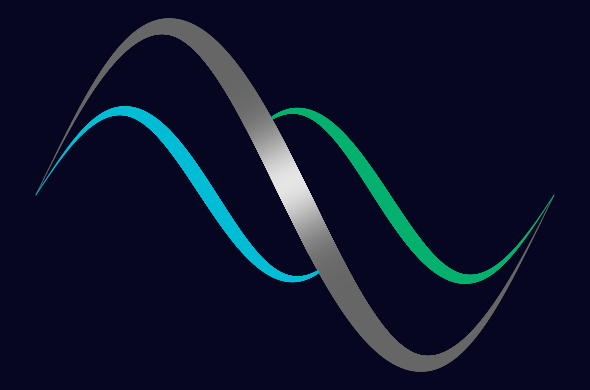

In [97]:
fig, ax = plt.subplots(figsize=(6, 4), facecolor="#060620")
ax.set_facecolor('#060620')

x = np.linspace(0, 2*np.pi, 1000)
y = 0.2 * np.sin(x)  # Reduced amplitude for flatter wave

linewidths = 0.5 + 20 * (np.sin(x/2)**2)

for i in range(len(x)-1):
    # Brightness varies from grey to white based on thickness
    brightness = (np.sin(x[i]/2)**2) ** 50
    color = (0.4 + 0.5*brightness, 0.4 + 0.5*brightness, 0.4 + 0.5*brightness)
    ax.plot(x[i:i+2], y[i:i+2], color=color, linewidth=linewidths[i])

#for i in range(len(x)-1):
#    ax.plot(x[i:i+2], y[i:i+2], color='#808080', linewidth=linewidths[i])

y2 = 0.1 * np.sin(1.5*x)  # Half amplitude, double frequency

linewidths2 = 0.5 + 10 * (np.sin(.8*x)**2)

y3 = 0.1 * np.sin(1.5*x+(np.pi))  # Half amplitude, double frequency

for i in range(int((len(x))/2+43)):
    ax.plot(x[i:i+2], y2[i:i+2], color='#00bcd4', linewidth=linewidths2[i])

linewidths3 = 0.5 + 10 * (np.sin(.8*(2*np.pi - x))**2)

for i in range(int((len(x))/2-43), len(x)-1):
    ax.plot(x[i:i+2], y3[i:i+2], color="#03b06d", linewidth=linewidths3[i])
    
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()
